In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuración para que los gráficos se vean mejor
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
import pandas as pd

# Cargar datos desde Kaggle

In [3]:
import kagglehub
import os

# Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("fjcob1/idealista-madrid")
print("Path to dataset files:", path)

# Cargar el archivo Datos.csv
df = pd.read_csv(os.path.join(path, 'Datos.csv'))

100%|██████████| 1.69M/1.69M [00:00<00:00, 106MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fjcob1/idealista-madrid/versions/2


In [4]:
df.head(3)

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/


In [ ]:
# import pandas as pd

# ruta = '/content/sample_data/Datos.csv'

# # Leer el dataset
# df = pd.read_csv(ruta)

In [5]:
# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [6]:
df = pd.DataFrame(df)
df.head(2)

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/


# Dimensiones del dataset

In [7]:
df.shape

(11826, 14)

# Información general

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  object 
 1   zona            11826 non-null  object 
 2   titulo          11826 non-null  object 
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  object 
 8   localizacion    10730 non-null  object 
 9   planta          10601 non-null  object 
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  object 
 12  descripcion     11761 non-null  object 
 13  Enlace          11826 non-null  object 
dtypes: float64(1), int64(4), object(9)
memory usage: 1.3+ MB


# Columnas disponibles

In [9]:
print(df.columns.tolist())

['provincia', 'zona', 'titulo', 'PrecioActual', 'PrecioAnterior', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'planta', 'baños', 'tags', 'descripcion', 'Enlace']


# Estadistica descriptiva

In [10]:
df.describe()

,PrecioActual,PrecioAnterior,metros,habitaciones,baños
count,1.182600e+04,1.182600e+04,11826.000000,11460.000000,11826.000000
mean,1.030501e+06,7.359704e+04,153.790039,2.847731,0.394047
std,1.237718e+06,3.639753e+05,766.217750,1.432402,0.882134
min,1.200000e+04,0.000000e+00,11.000000,1.000000,0.000000
25%,2.890000e+05,0.000000e+00,68.000000,2.000000,0.000000
50%,6.200000e+05,0.000000e+00,103.000000,3.000000,0.000000
75%,1.329000e+06,0.000000e+00,160.000000,3.000000,0.000000
max,2.300000e+07,8.450000e+06,75000.000000,20.000000,7.000000


# Estadística para columnas categóricas

In [11]:
df.describe(include='object')

,provincia,zona,titulo,ascensor,localizacion,planta,tags,descripcion,Enlace
count,11826,11826,11826,11033,10730,10601,11664,11761,11826
unique,1,21,5499,2,2,27,8370,10924,11826
top,madrid,barrio-de-salamanca,"Piso en Goya, Madrid",S,EXTERIOR,1ª,"PISO,OPORTUNIDAD",OBRA NUEVA DE VIVIENDAS TURÍSTICAS DE LUJO E I...,https://www.idealista.com/inmueble/106876203/
freq,11826,2018,203,8419,9087,2108,158,16,1


# Limpieza de datos

## Identificar valores faltantes

In [12]:
print(df.isnull().sum())

provincia            0
zona                 0
titulo               0
PrecioActual         0
PrecioAnterior       0
metros               0
habitaciones       366
ascensor           793
localizacion      1096
planta            1225
baños                0
tags               162
descripcion         65
Enlace               0
dtype: int64


## Visualizar valores faltantes

In [13]:
# Porcentaje de datos faltantes por columna
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

habitaciones     3.094876
ascensor         6.705564
localizacion     9.267715
planta          10.358532
tags             1.369863
descripcion      0.549636
dtype: float64


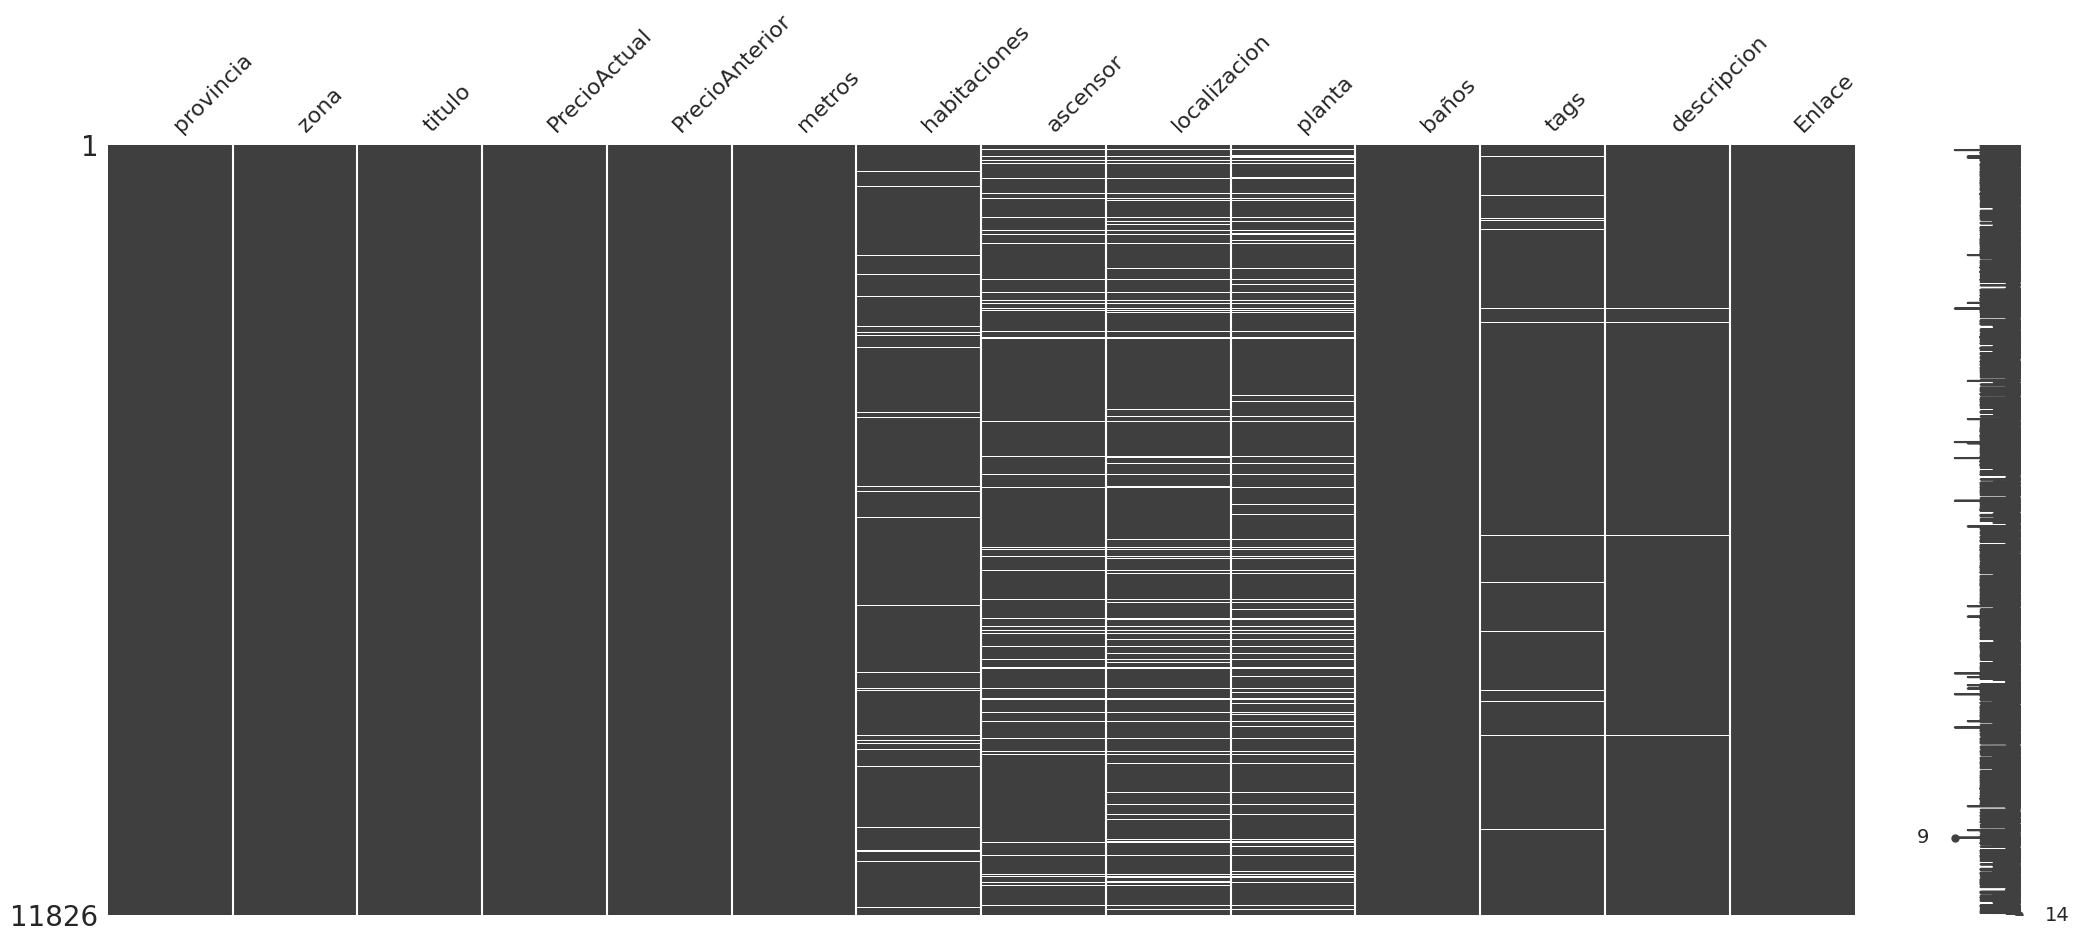

In [14]:
import missingno as msngno
msngno.matrix(df)
plt.show()

## Eliminar columnas irrelevantes

In [15]:
# Eliminar columnas que no aportan al análisis
df = df.drop(['provincia', 'PrecioAnterior', 'Enlace'], axis=1)

# Ver cómo quedó el dataset después de eliminar columnas
print("Dataset después de eliminar columnas:")
df.head()

Dataset después de eliminar columnas:


,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta..."
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co..."


In [16]:
df.shape

(11826, 11)

## Valores únicos de columnas con falta de datos

### Columna planta

In [17]:
valores_unicos = df['planta'].unique()
print(valores_unicos)

['5ª' '1ª' '2ª' 'BAJO' '3ª' '6ª' nan '4ª' '16ª' '13ª' '9ª' '7ª' '10ª' '8ª'
 '14ª' '11ª' '12ª' 'ENTREPLANTA' 'SÓTANO' '-1' '15ª' '17ª' '20ª' '-2'
 '27ª' '22ª' '21ª' '18ª']


### Columna habitaciones

In [18]:
valores_unicos = df['habitaciones'].unique()
print(valores_unicos)

[ 2.  3.  1.  6.  5.  4. 20. nan  9. 16.  7.  8. 15. 10. 11. 13. 12. 17.]


In [19]:
cuantos = df[df['habitaciones'] > 8]['habitaciones'].count()
print(cuantos)

64


### Borrar los inmuebles con más de 8 habitaciones

In [20]:
df = df[df['habitaciones'] <= 8]
cuantos = df[df['habitaciones'] > 8]['habitaciones'].count()
print(cuantos)

0


### Columna ascensor

In [21]:
valores_unicos = df['ascensor'].unique()
print(valores_unicos)

['S' 'N' nan]


### Columna localizacion

In [22]:
valores_unicos = df['localizacion'].unique()
print(valores_unicos)

['EXTERIOR' nan 'INTERIOR']


### Columna metros

In [23]:
valores_unicos = df['metros'].unique()
print(valores_unicos)

[   69    91    36    58   140   135    81    43   500   139    90   375
    80   152    67    76   379    92   124   130    55   110    99   240
   114    59   158    41   196   279    87   308    68   105   380   219
    63    47    93    72    82   132    57    78   162   182   550   265
   136    89   200   368    45   138    56    83   420  1100   100   128
   157    70   113   108    88   115   137    95   175   434    74    97
    60    84    66   131   170   121    75   165   119    62   244   106
   492   291   104    50   237   232    40    86   125    42   142   405
    98    65   185   199   236   117   390    85    34   275   325   208
   118    64    54   306   101   462   133   220   171    44   261   159
   155   146    35  1768   164    53   112   251   340   305   120   235
   223    49   386   216    46   123   666   150   578   346    77    96
   103   337   766   724   198   147   180   127   262   206    52    48
   238   107   156    37    33   440   203   510   

In [24]:
cuantos = df[df['metros'] > 1000]['metros'].count()
print(cuantos)

39


### Borrar los inmuebles con más de 1000 metros

In [25]:
df = df[df['metros'] <= 1000]
cuantos = df[df['metros'] > 1000]['metros'].count()
print(cuantos)

0


In [26]:
df.tail(3)

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion
11823,tetuan,"Piso en calle del Capitán Blanco Argibay, Vald...",219000,56,1.0,S,EXTERIOR,BAJO,0,"APARTAMENTO,METRO",¡IDEAL INVERSORES! Precioso apartamento en Val...
11824,carabanchel,"Piso en calle de Aceuchal, Vista Alegre, Madrid",165000,74,3.0,N,EXTERIOR,2ª,0,"OPORTUNIDAD,METRO","**IDEAL INVERSORES, NO DEJES PASAR ESTA OPORTU..."
11825,san-blas,"Piso en calle de los Hermanos García Noblejas,...",178000,54,2.0,S,EXTERIOR,BAJO,0,"PISO,REFORMADO,LUMINOSO,INMOBILIARIA,METRO",Establés inmobiliaria abogados vende piso en h...


# Analisis Univariado

## Variable numérica habitaciones

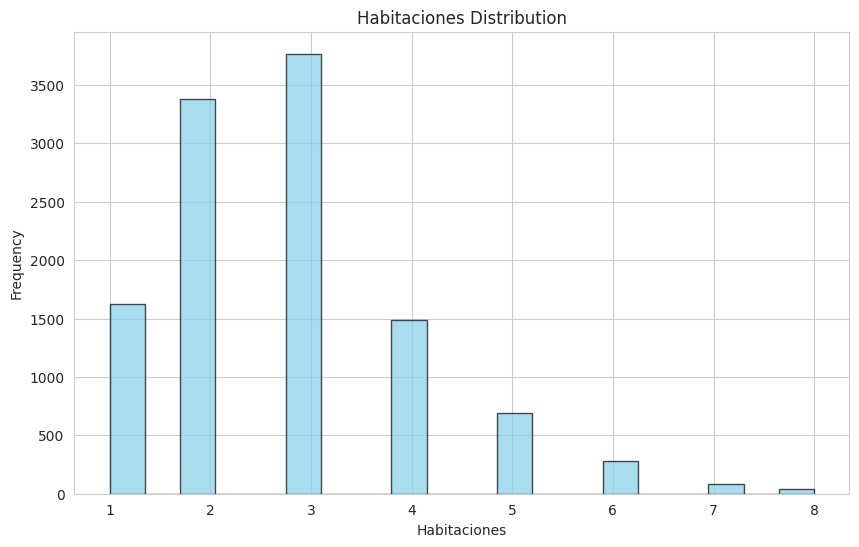

In [27]:
# Histograma para ver la distribución de habitaciones
# bins=20 divide las habitaciones en 20 rangos
# edgecolor='black' añade un borde negro a cada barra para distinguirlas mejor
# alpha=0.7 hace las barras ligeramente transparentes
df['habitaciones'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Habitaciones Distribution')
plt.xlabel('Habitaciones')
plt.ylabel('Frequency')
plt.show()

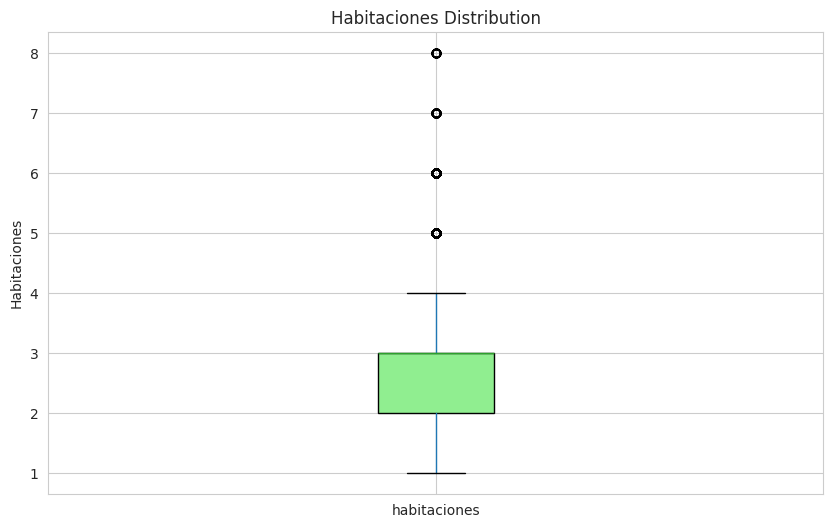

In [28]:
# Boxplot para detectar valores extremos (outliers)
# Un boxplot muestra la distribución de los datos y resalta valores anómalos
df.boxplot(column='habitaciones', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('Habitaciones Distribution')  # Distribución del precio de los tickets
plt.ylabel('Habitaciones')
plt.show()

### Variable numérica baños

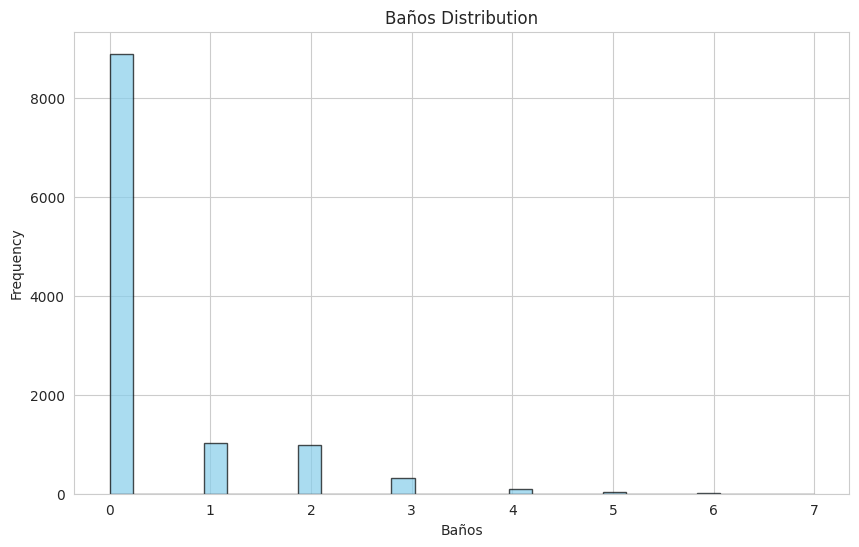

In [29]:
# Histograma para ver la distribución de habitaciones
# bins=30 divide las habitaciones en 20 rangos
# edgecolor='black' añade un borde negro a cada barra para distinguirlas mejor
# alpha=0.7 hace las barras ligeramente transparentes
df['baños'].plot(kind='hist', bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Baños Distribution')
plt.xlabel('Baños')
plt.ylabel('Frequency')
plt.show()

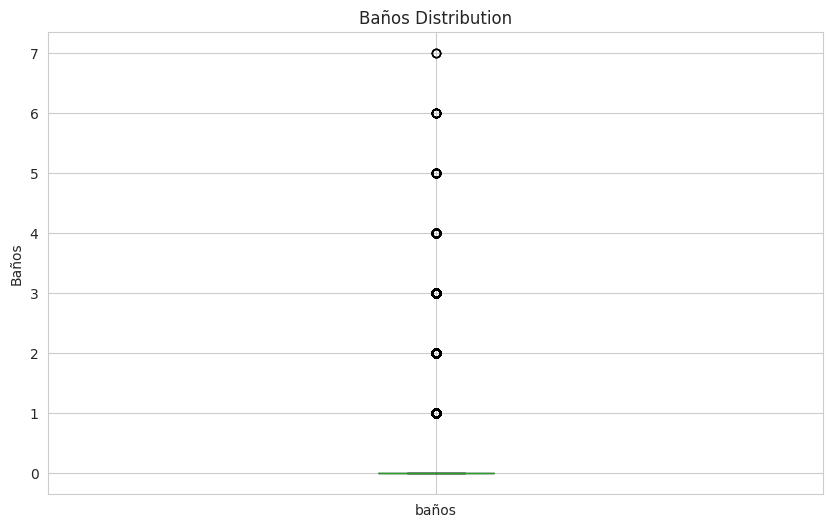

In [30]:
df.boxplot(column='baños', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('Baños Distribution')  # Distribución del precio de los tickets
plt.ylabel('Baños')
plt.show()

In [31]:
df['baños'].value_counts()

,count
baños,
0,8885
1,1030
2,986
3,317
4,87
5,33
6,16
7,3


### Borro la columna de baños porque casi todos los inmuebles tienen 0 baños y eso es un error

In [32]:
df.drop('baños', axis=1, inplace=True)
df.head(3)

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...


### Variable numérica de metros

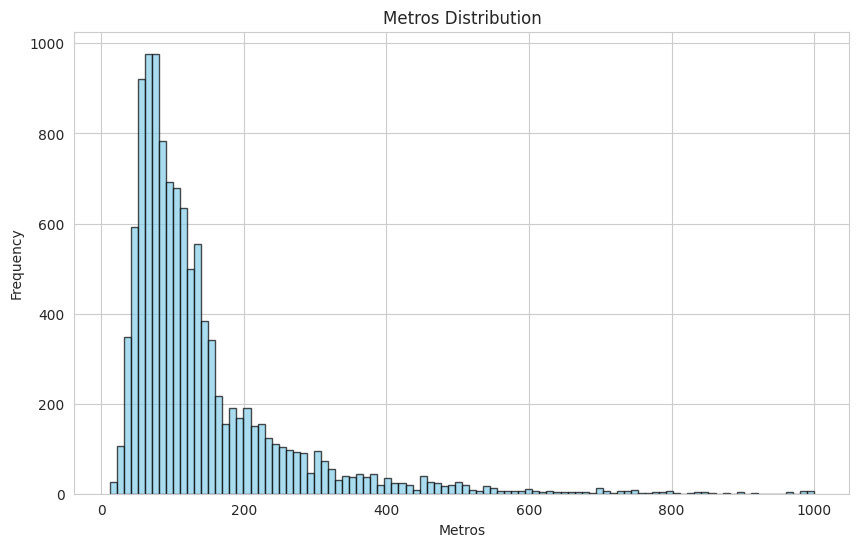

In [33]:
df['metros'].plot(kind='hist', bins=100, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Metros Distribution')
plt.xlabel('Metros')
plt.ylabel('Frequency')
plt.show()

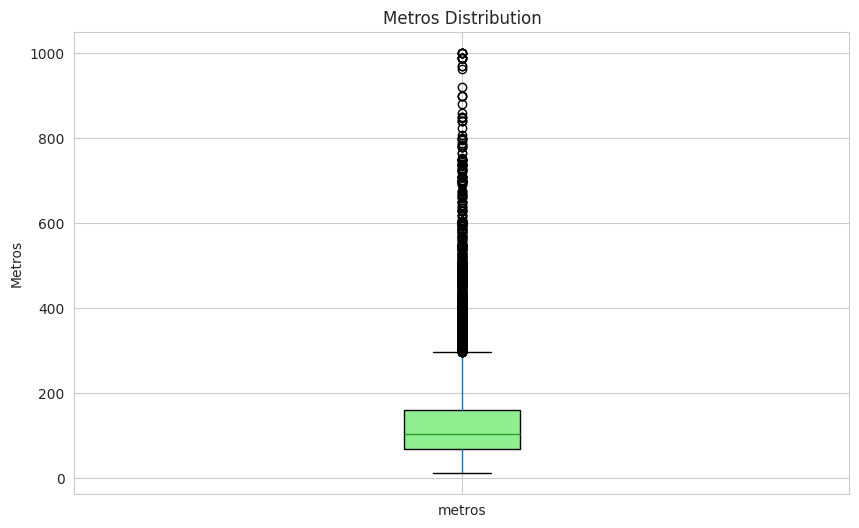

In [34]:
df.boxplot(column='metros', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('Metros Distribution')  # Distribución del precio de los tickets
plt.ylabel('Metros')
plt.show()

### Variable numérica de precioActual

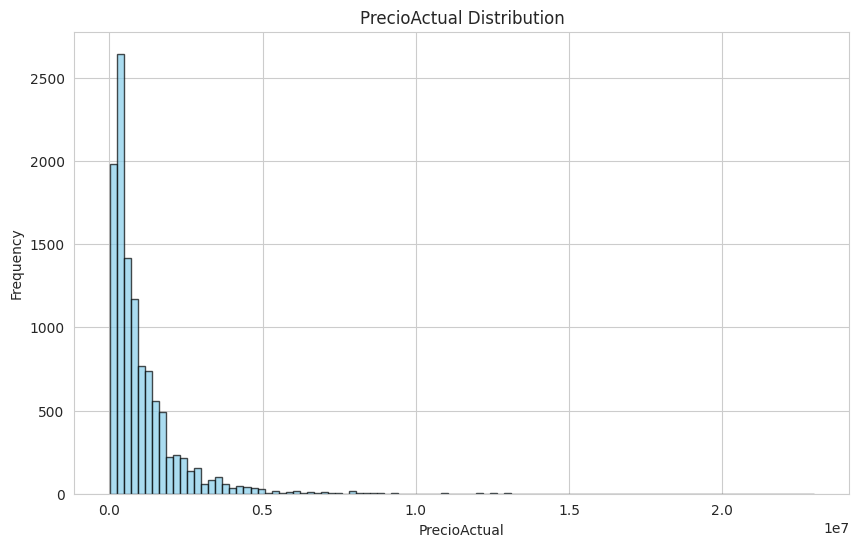

In [35]:
df['PrecioActual'].plot(kind='hist', bins=100, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('PrecioActual Distribution')
plt.xlabel('PrecioActual')
plt.ylabel('Frequency')
plt.show()

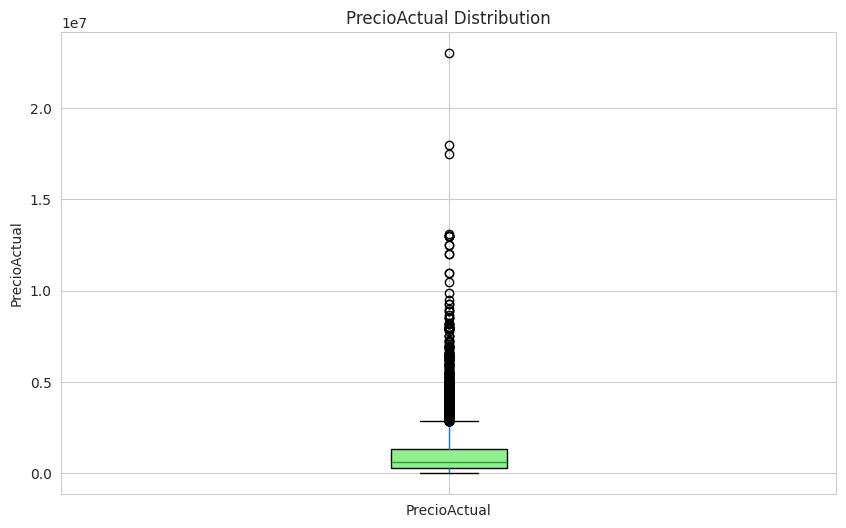

In [36]:
df.boxplot(column='PrecioActual', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('PrecioActual Distribution')  # Distribución del precio de los tickets
plt.ylabel('PrecioActual')
plt.show()

### Modificar el DataFrame para que las plantas sean numéricas

In [37]:
valores_unicos = df['planta'].unique()
print(valores_unicos)

['5ª' '1ª' '2ª' 'BAJO' '3ª' '6ª' nan '4ª' '16ª' '13ª' '9ª' '7ª' '10ª' '8ª'
 '14ª' '11ª' '12ª' 'ENTREPLANTA' 'SÓTANO' '-1' '15ª' '17ª' '20ª' '-2'
 '27ª' '22ª' '21ª' '18ª']


In [38]:
# Quitar el ª de las plantas
df['plantaN'] = df['planta'].str.split('ª', n=1).str[0]

In [39]:
# Comprobación
valores_unicos = df['plantaN'].unique()
print(valores_unicos)

['5' '1' '2' 'BAJO' '3' '6' nan '4' '16' '13' '9' '7' '10' '8' '14' '11'
 '12' 'ENTREPLANTA' 'SÓTANO' '-1' '15' '17' '20' '-2' '27' '22' '21' '18']


### Se hace una copia del dataframe por si algún cambio sale mal y poder volver a los datos de aquí.

In [40]:
df_copia = df.copy()

# xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

In [71]:
df = df_copia.copy()

In [72]:
df.head(5)

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion,plantaN
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,5
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,1
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,2
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",BAJO
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",2


# xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

In [75]:
cuantos = df[df['plantaN'] == 'BAJO']['plantaN'].count()
print(cuantos)

1397


In [ ]:
# Poner los siguientes valores según planta : ENTREPLANTA = 0.5 - SÓTANO = -1 - BAJO = 0 - nan = media
df['plantaN'] = df['plantaN'].replace('BAJO', '0')

In [77]:
cuantos = df[df['plantaN'] == 'BAJO']['plantaN'].count()
print(cuantos)

0


In [78]:
df.head()

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion,plantaN
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,5
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,1
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,2
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",0
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",2


In [79]:
df['plantaN'] = df['plantaN'].replace('ENTREPLANTA', '0.5')
cuantos = df[df['plantaN'] == 'ENTREPLANTA']['plantaN'].count()
print(cuantos)

0


In [80]:
df['plantaN'] = df['plantaN'].replace('SÓTANO', '-1')
cuantos = df[df['plantaN'] == 'SÓTANO']['plantaN'].count()
print(cuantos)

0


In [81]:
df.head(5)

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion,plantaN
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,5
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,1
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,2
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",0
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",2


In [82]:
cuantos = df[df['localizacion'] == 'INTERIOR']['localizacion'].count()
print(cuantos)

1518


In [83]:
cuantos = df[df['localizacion'] == 'EXTERIOR']['localizacion'].count()
print(cuantos)

8849


In [85]:
# Poner el tipo de la columna a float para poder ponerle la media a los nan
df['plantaN'] = df['plantaN'].astype(float)

In [86]:
df['plantaN'] = df['plantaN'].fillna(df['plantaN'].mean())

In [87]:
# Redondear los decimales de la columna a 2 decimales
df['plantaN'] = df['plantaN'].round(2)

In [88]:
valores_unicos = df['plantaN'].unique()
print(valores_unicos)

[ 5.    1.    2.    0.    3.    6.    2.74  4.   16.   13.    9.    7.
 10.    8.   14.   11.   12.    0.5  -1.   15.   17.   20.   -2.   27.
 22.   21.   18.  ]


In [89]:
df.head(5)

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion,plantaN
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,5.0
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,1.0
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,2.0
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",0.0
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",2.0


In [90]:
# Crea la columna de tipoInmueble
df['tipoInmueble'] = df['titulo'].str.split(' en ', n=1).str[0]
# La comprueba
valores_unicos = df['tipoInmueble'].unique()
print(valores_unicos)

['Piso' 'Dúplex' 'Chalet adosado' 'Ático' 'Chalet pareado'
 'Casa o chalet independiente' 'Chalet' 'Casa rural']


In [91]:
# Creo la columna de direccion
df['direccion'] = df['titulo'].str.split(' en ', n=1).str[1]
# Lo compruebo
valores_unicos = df['direccion'].unique()
print(valores_unicos)

['calle de San Marcelo, 22, Ventas, Madrid'
 'calle Cabo Nicolás Mur, San Isidro, Madrid'
 'calle de Rodas, Lavapiés-Embajadores, Madrid' ...
 'calle de Carabelos, 35, San Fermín, Madrid'
 'calle Gran Vía, Chueca-Justicia, Madrid'
 'calle de Aceuchal, Vista Alegre, Madrid']


In [92]:
df[['titulo', 'tipoInmueble', 'direccion']]

,titulo,tipoInmueble,direccion
0,"Piso en calle de San Marcelo, 22, Ventas, Madrid",Piso,"calle de San Marcelo, 22, Ventas, Madrid"
1,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",Piso,"calle Cabo Nicolás Mur, San Isidro, Madrid"
2,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",Piso,"calle de Rodas, Lavapiés-Embajadores, Madrid"
3,"Piso en calle de Ferroviarios, Almendrales, Ma...",Piso,"calle de Ferroviarios, Almendrales, Madrid"
4,"Dúplex en Bellas Vistas, Madrid",Dúplex,"Bellas Vistas, Madrid"
...,...,...,...
11821,"Piso en calle del Amparo, Lavapiés-Embajadores...",Piso,"calle del Amparo, Lavapiés-Embajadores, Madrid"
11822,"Piso en calle Gran Vía, Chueca-Justicia, Madrid",Piso,"calle Gran Vía, Chueca-Justicia, Madrid"
11823,"Piso en calle del Capitán Blanco Argibay, Vald...",Piso,"calle del Capitán Blanco Argibay, Valdeacedera..."
11824,"Piso en calle de Aceuchal, Vista Alegre, Madrid",Piso,"calle de Aceuchal, Vista Alegre, Madrid"


In [96]:
display(df.head(10))

,zona,titulo,PrecioActual,metros,habitaciones,ascensor,localizacion,planta,tags,descripcion,plantaN,tipoInmueble,direccion
0,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,69,2.0,S,EXTERIOR,5ª,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,5.00,Piso,"calle de San Marcelo, 22, Ventas, Madrid"
1,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,91,3.0,N,EXTERIOR,1ª,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,1.00,Piso,"calle Cabo Nicolás Mur, San Isidro, Madrid"
2,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,36,1.0,S,NaN,2ª,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,2.00,Piso,"calle de Rodas, Lavapiés-Embajadores, Madrid"
3,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,58,1.0,S,INTERIOR,BAJO,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",0.00,Piso,"calle de Ferroviarios, Almendrales, Madrid"
4,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,140,3.0,S,EXTERIOR,2ª,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",2.00,Dúplex,"Bellas Vistas, Madrid"
5,arganzuela,"Piso en Mazarredo, 18, Imperial, Madrid",1257000,135,3.0,S,EXTERIOR,3ª,"VIVIENDA,VISTAS,PISCINA,IMPRESIONANTE,EXTERIOR",Un lugar que te cambiará la vida.Magnifico pro...,3.00,Piso,"Mazarredo, 18, Imperial, Madrid"
6,barrio-de-salamanca,"Piso en calle de Núñez de Balboa, Recoletos, M...",830000,81,1.0,S,INTERIOR,6ª,"PISO,LUMINOSO,EQUIPADA,PORTERO,PATIO",Piso muy luminoso y con ubicación ideal en el ...,6.00,Piso,"calle de Núñez de Balboa, Recoletos, Madrid"
7,puente-de-vallecas,"Piso en calle de Rodríguez Espinosa, s/n, Palo...",70000,43,1.0,N,EXTERIOR,1ª,OPORTUNIDAD,"OPORTUNIDAD INMUEBLE SIN POSESIÓN, NO SE PUEDE...",1.00,Piso,"calle de Rodríguez Espinosa, s/n, Palomeras Ba..."
8,moncloa,Chalet adosado en calle de la Isla de Alegranz...,2150000,500,6.0,NaN,NaN,NaN,"EXCLUSIVA,INMOBILIARIA",Mavericks Inmobiliaria comercializa con caráct...,2.74,Chalet adosado,"calle de la Isla de Alegranza, 51, Ciudad Univ..."
9,chamberi,"Piso en Blanca de Navarra, 4, Almagro, Madrid",1847800,139,2.0,S,EXTERIOR,3ª,"VIVIENDA,TERRAZA,PISCINA,GARAJE",Blanca de Navarra 4 es una promoción de obra n...,3.00,Piso,"Blanca de Navarra, 4, Almagro, Madrid"


# --------------------------------------------------------------------

# Prueba de Código Postal

In [93]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [ ]:
# 1. Crear DataFrame de ejemplo
data = {'direccion': [
    'Calle de Alcalá, 1, Madrid',
    'Gran Vía, 10, Madrid',
    'Calle de Serrano, 50, Madrid',
    'Paseo de la Castellana, 100, Madrid'
]}

data = {'direccion': [
    'calle de San Marcelo, 22, Ventas, Madrid',
    'calle Cabo Nicolás Mur, San Isidro, Madrid',
    'calle de Rodas, Lavapiés-Embajadores, Madrid',
    'Bellas Vistas, Madrid'
]}

df_pru = pd.DataFrame(data)

# 2. Inicializar Nominatim Geocoder
# IMPORTANTE: Usa un user_agent único para evitar bloqueos
geolocator = Nominatim(user_agent="mi_apli_juanma_madrid_cp", timeout=10)

# Añadir un "rate limiter" para limitar las peticiones a 1 por segundo
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# 3. Aplicar geocodificación
# La función devuelve un objeto location, extraemos la dirección completa
# df_pru['location'] = df_pru['direccion'].apply(geocode)

# # 4. Extraer el código postal de los resultados
# def extraer_cp(location):
#     if location and 'address' in location.raw:
#         address = location.raw['address']
#         # Buscar el 'postcode' en la respuesta
#         print(address)
#         return address.get('postcode', None)
#     return None

# df_pru['codigo_postal'] = df_pru['location'].apply(extraer_cp)

# NUEVO
df['location'] = df['direccion'].apply(lambda x: geocode(x, addressdetails=True))

# 5. Extraer el código postal del objeto "raw"
def obtener_postal(location):
    if location and 'postcode' in location.raw['address']:
        return location.raw['address']['postcode']
    else:
        return None

df['codigo_postal'] = df['location'].apply(obtener_postal)

# 5. Limpiar y visualizar
# Eliminamos la columna de objetos 'location'
#df_pru = df_pru.drop(columns=['location'])
#print(df_pru)

KeyError: 'address'

In [102]:
pd.set_option('display.max_colwidth', None)

df_pru.head(5)

,direccion,location,codigo_postal
0,"calle de San Marcelo, 22, Ventas, Madrid","(22, Calle de San Marcelo, La Elipa, Ventas, Ciudad Lineal, Madrid, Comunidad de Madrid, 28017, España, (40.4269541, -3.655905))",None
1,"calle Cabo Nicolás Mur, San Isidro, Madrid","(Calle Cabo Nicolás Mur, San Isidro, Carabanchel, Madrid, Comunidad de Madrid, 28019, España, (40.3948877, -3.7334918))",None
2,"calle de Rodas, Lavapiés-Embajadores, Madrid",None,None
3,"Bellas Vistas, Madrid","(Bellas Vistas, Tetuán, Madrid, Comunidad de Madrid, España, (40.4526848, -3.7072396))",None
